# Step 1: Load & Explore Data
Dataset: Processed_RUSSELL.csv (Russell 2000 stock index)

**Tasks:**
1. Load the data
2. Understand the shape and columns
3. Remove `-F` forecast columns and `Name` column
4. Handle missing values using 5th-order moving average
5. Descriptive statistics and visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load Data

In [2]:
df = pd.read_csv('../data/Processed_RUSSELL.csv', parse_dates=['Date'], index_col='Date')
print(f'Shape: {df.shape}')  # (rows, columns)
df.head(3)

Shape: (1984, 83)


,Close,Volume,mom,mom1,mom2,mom3,ROC_5,ROC_10,ROC_15,ROC_20,...,NZD,silver-F,RUSSELL-F,S&P-F,CHF,Dollar index-F,Dollar index,wheat-F,XAG,XAU
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-31,625.390015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.03,0.26,-1.08,-1.00,-0.11,-0.08,-0.06,-0.48,0.30,0.39
2010-01-04,640.099976,0.921723,0.023521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.52,3.26,1.61,1.62,-0.57,-0.59,-0.42,3.12,3.91,2.10
2010-01-05,638.489990,-0.375903,-0.002515,0.023521,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.07,1.96,-0.20,0.31,0.43,0.03,0.12,-0.90,1.42,-0.12


## 2. Remove Forecast Columns (ending in -F) and Name column
Homework instruction: all columns whose name ends in 'F' are pre-computed forecasts — remove them.

In [3]:
# Identify columns to drop
f_cols = [c for c in df.columns if c.endswith('-F') or c.endswith('F') and c != 'WFC']
# More precise: ends with '-F' pattern OR is RUSSELL-F specifically
f_cols = [c for c in df.columns if c.endswith('-F')]
print(f'Forecast columns to remove ({len(f_cols)}): {f_cols}')

df = df.drop(columns=f_cols + ['Name'], errors='ignore')
print(f'\nShape after removal: {df.shape}')
print(f'Remaining columns ({len(df.columns)}): {list(df.columns)}')

Forecast columns to remove (16): ['CAC-F', 'copper-F', 'DAX-F', 'DJI-F', 'FTSE-F', 'gold-F', 'HSI-F', 'KOSPI-F', 'NASDAQ-F', 'GAS-F', 'Nikkei-F', 'silver-F', 'RUSSELL-F', 'S&P-F', 'Dollar index-F', 'wheat-F']

Shape after removal: (1984, 66)
Remaining columns (66): ['Close', 'Volume', 'mom', 'mom1', 'mom2', 'mom3', 'ROC_5', 'ROC_10', 'ROC_15', 'ROC_20', 'EMA_10', 'EMA_20', 'EMA_50', 'EMA_200', 'DTB4WK', 'DTB3', 'DTB6', 'DGS5', 'DGS10', 'Oil', 'Gold', 'DAAA', 'DBAA', 'GBP', 'JPY', 'CAD', 'CNY', 'AAPL', 'AMZN', 'GE', 'JNJ', 'JPM', 'MSFT', 'WFC', 'XOM', 'FCHI', 'FTSE', 'GDAXI', 'DJI', 'HSI', 'IXIC', 'SSEC', 'S&P', 'NYSE', 'TE1', 'TE2', 'TE3', 'TE5', 'TE6', 'DE1', 'DE2', 'DE4', 'DE5', 'DE6', 'CTB3M', 'CTB6M', 'CTB1Y', 'AUD', 'Brent', 'WIT-oil', 'EUR', 'NZD', 'CHF', 'Dollar index', 'XAG', 'XAU']


## 3. Check Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_%', ascending=False)
print(f'Columns with missing values: {len(missing_summary)}')
missing_summary

Columns with missing values: 39


,missing_count,missing_%
CAD,483,24.34
JPY,479,24.14
CNY,479,24.14
GBP,478,24.09
SSEC,238,12.00
EMA_200,199,10.03
HSI,170,8.57
FTSE,71,3.58
GDAXI,67,3.38
EMA_50,49,2.47


## 4. Handle Missing Values — 5th-Order Moving Average

**Concept:** Replace each missing value with the average of the 2 values before and 2 values after it (window=5, centered).

$$\hat{x}_t = \frac{x_{t-2} + x_{t-1} + x_t + x_{t+1} + x_{t+2}}{5}$$

In [7]:
def fill_with_moving_average(series, order=5):
    """Fill missing values using centered moving average of given order."""
    filled = series.copy()
    ma = series.rolling(window=order, center=True, min_periods=1).mean()
    filled = filled.fillna(ma)
    # If still NaN (at edges), use forward fill then backward fill
    filled = filled.ffill().bfill()
    return filled

# Apply to all columns
df_clean = df.apply(fill_with_moving_average, order=5)

# Verify no missing values remain
remaining_missing = df_clean.isnull().sum().sum()
print(f'Missing values remaining after cleaning: {remaining_missing}')
print(f'Clean dataset shape: {df_clean.shape}')

Missing values remaining after cleaning: 0
Clean dataset shape: (1984, 66)


## 5. Descriptive Statistics

In [8]:
df_clean.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
Close,1984.0,1018.5995,243.2203,586.4900,799.5200,1074.5950,1195.7025,1512.0900
Volume,1984.0,0.0204,0.2341,-0.8310,-0.0852,-0.0017,0.0899,4.4241
mom,1984.0,0.0005,0.0128,-0.0891,-0.0057,0.0010,0.0075,0.0694
mom1,1984.0,0.0005,0.0128,-0.0891,-0.0057,0.0010,0.0075,0.0694
mom2,1984.0,0.0005,0.0128,-0.0891,-0.0057,0.0010,0.0075,0.0694
...,...,...,...,...,...,...,...,...
NZD,1984.0,-0.0015,0.7528,-4.1200,-0.4500,-0.0100,0.4700,3.4300
CHF,1984.0,-0.0023,0.7427,-15.7600,-0.3400,0.0000,0.3500,9.6800
Dollar index,1984.0,0.0103,0.4950,-4.2800,-0.2700,0.0000,0.2800,3.9800
XAG,1984.0,0.0104,1.8325,-12.9300,-0.8400,0.0300,0.9200,6.5300


## 6. Visualize the Target Variable (Close price)

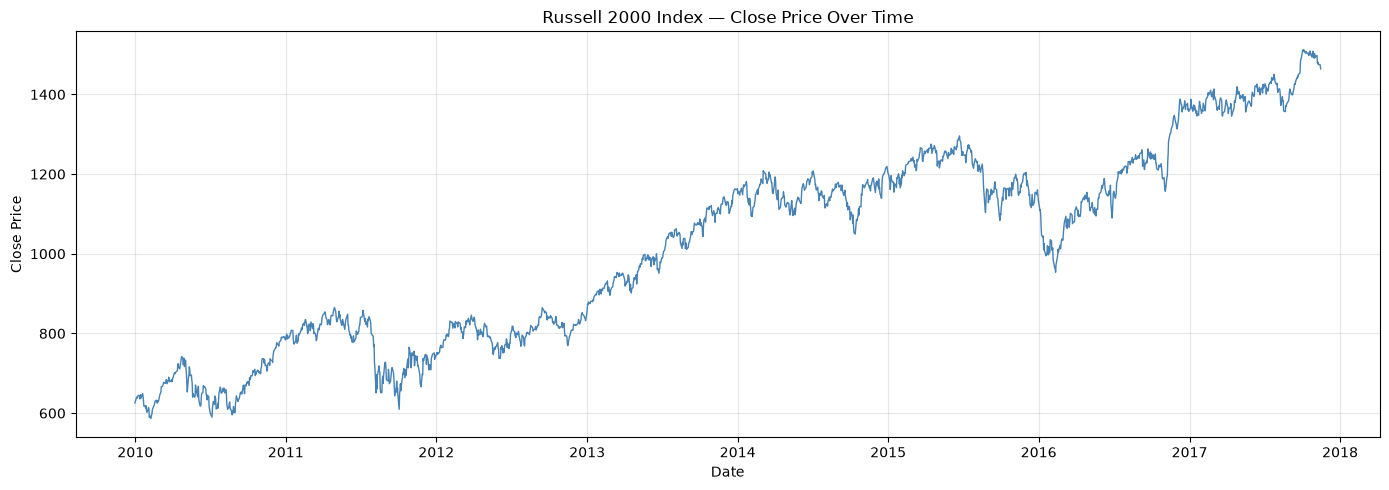

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df_clean.index, df_clean['Close'], color='steelblue', linewidth=1)
plt.title('Russell 2000 Index — Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Correlation Heatmap (top variables correlated with Close)

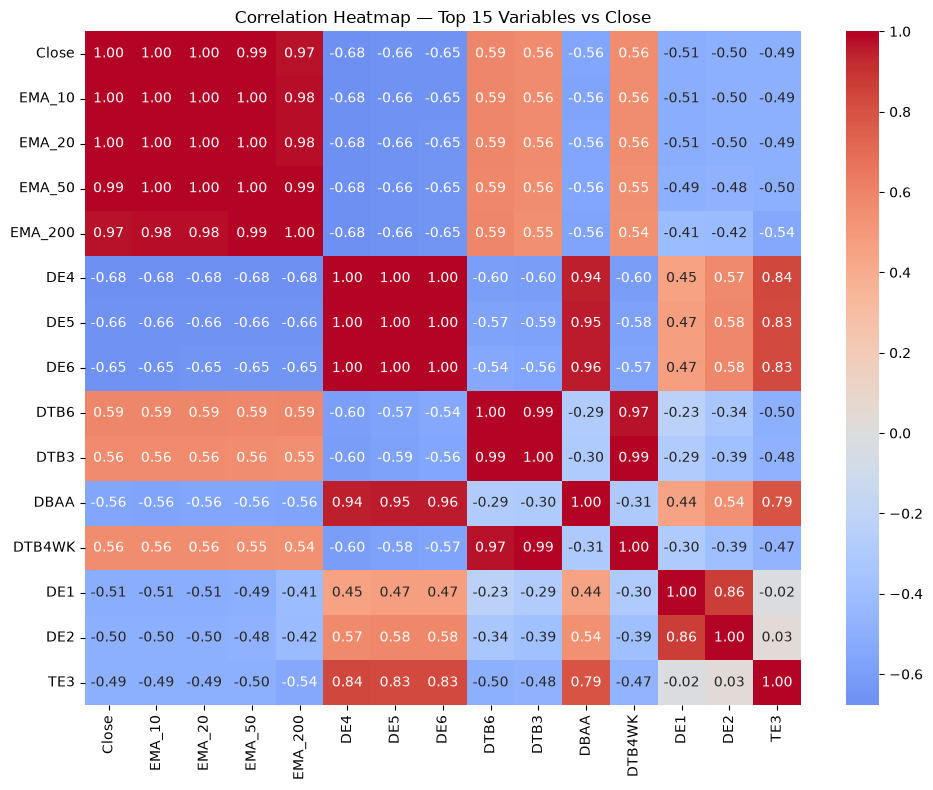

In [10]:
# Find top 15 variables most correlated with Close
corr_with_close = df_clean.corr()['Close'].abs().sort_values(ascending=False)
top_vars = corr_with_close.head(15).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[top_vars].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Top 15 Variables vs Close')
plt.tight_layout()
plt.show()

## 8. Save Clean Data for Next Notebook

In [11]:
df_clean.to_csv('../data/RUSSELL_clean.csv')
print('Clean data saved to ../data/RUSSELL_clean.csv')
print(f'Final shape: {df_clean.shape}')

Clean data saved to ../data/RUSSELL_clean.csv
Final shape: (1984, 66)
